# MIP Formulation Comparison Experiment

Dit notebook voert een subset van simulatieruns uit om twee MIP-formuleringen te vergelijken.

**Workflow:**
1. Stel `EXPERIMENT_NAME` in en run alle cellen → resultaten opgeslagen in `results/<EXPERIMENT_NAME>/`
2. Pas `mip_base.py` aan
3. Stel een nieuwe `EXPERIMENT_NAME` in en run opnieuw
4. Ga naar het **Analyse**-gedeelte en vul beide namen in om te vergelijken

## 1. Setup

In [1]:
import sys, io, warnings, traceback, time
from pathlib import Path
from contextlib import redirect_stdout

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))

from run_simulation import run_simulation
from utils.metrics import (
    compute_metrics, build_result_row, save_result_row,
    aggregate_config,
)

print("Imports OK")

Imports OK


## 2. Experimentconfiguratie

**Pas hier `EXPERIMENT_NAME` aan** voor elke run.

In [2]:
# ── !! HANDMATIG AANPASSEN !! ──────────────────────────────────────────────
EXPERIMENT_NAME = "eq_formulation"   # bijv. "geq_formulation" of "eq_formulation"
# ──────────────────────────────────────────────────────────────────────────

RESULTS_BASE = Path.cwd().parent / "results" / "mip_comparison"
RESULTS_DIR  = RESULTS_BASE / EXPERIMENT_NAME
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

N_RUNS    = 20
N_FREIGHT = 182
PHASE     = 99   # aparte fase-tag voor dit experiment
SEEDS     = list(range(1, N_RUNS + 1))

# ── Configuraties om te testen ─────────────────────────────────────────────
# Subset van Fase 1: één trigger × één priority als referentie
TRIGGER_CONFIGS = {
    "periodic": dict(
        trigger_strategy     = "periodic",
        periodic_freq        = 900,
        event_driven_freq    = 900,
        controller_freq      = 900,
        threshold_confidence = 0.40,
    ),
    "event_driven": dict(
        trigger_strategy     = "event_driven",
        event_driven_freq    = 900,
        controller_freq      = 900,
        periodic_freq        = 3600,
        threshold_confidence = 0.40,
    ),
}

PRIORITY_CONFIGS = {
    "no_priority": dict(
        objective_strategy = "static",
        weight_passenger   = 1,
        weight_freight     = 1,
        dynamic_threshold  = 180,
    ),
    "static": dict(
        objective_strategy = "static",
        weight_passenger   = 2,
        weight_freight     = 1,
        dynamic_threshold  = 180,
    ),
}

TRIGGER_ORDER  = list(TRIGGER_CONFIGS.keys())
PRIORITY_ORDER = list(PRIORITY_CONFIGS.keys())
CONFIGS        = [(t, p) for t in TRIGGER_ORDER for p in PRIORITY_ORDER]

def config_name(trigger, priority):
    return f"{trigger}_{priority}"

print(f"Experiment  : {EXPERIMENT_NAME}")
print(f"Results dir : {RESULTS_DIR}")
print(f"Seeds       : {N_RUNS}  |  n_freight = {N_FREIGHT}")
print(f"Configuraties ({len(CONFIGS)}):")
for t, p in CONFIGS:
    print(f"  {config_name(t, p)}")

Experiment  : eq_formulation
Results dir : /Users/ddw/Desktop/Rescheduling/results/mip_comparison/eq_formulation
Seeds       : 20  |  n_freight = 182
Configuraties (4):
  periodic_no_priority
  periodic_static
  event_driven_no_priority
  event_driven_static


## 3. Runs uitvoeren

Resume-safe: al voltooide seeds worden overgeslagen.

In [3]:
def completed_seeds(trigger, priority):
    csv_path = RESULTS_DIR / config_name(trigger, priority) / "raw_runs.csv"
    if not csv_path.exists():
        return set()
    return set(pd.read_csv(csv_path, usecols=["seed"])["seed"].tolist())


def run_one(trigger, priority, seed):
    tcfg = TRIGGER_CONFIGS[trigger]
    pcfg = PRIORITY_CONFIGS[priority]

    buf = io.StringIO()
    with redirect_stdout(buf):
        state, df_sim, meta, _ = run_simulation(
            n_freight = N_FREIGHT,
            seed      = seed,
            save      = False,
            **tcfg,
            **pcfg,
        )

    metrics = compute_metrics(df_sim)
    n_pass  = metrics.get("n_passenger", 0)
    total   = n_pass + N_FREIGHT if n_pass > 0 else N_FREIGHT
    frt_pct = N_FREIGHT / total if total > 0 else 0.15

    row = build_result_row(
        seed             = seed,
        phase            = PHASE,
        metrics          = metrics,
        meta             = meta,
        strategy_type    = trigger,
        periodic_rf      = tcfg["periodic_freq"],
        event_driven_rf  = tcfg["event_driven_freq"],
        controller_freq  = tcfg["controller_freq"],
        threshold_conf   = tcfg["threshold_confidence"],
        priority         = priority,
        weight_passenger = pcfg["weight_passenger"],
        weight_freight   = pcfg["weight_freight"],
        gamma            = pcfg["dynamic_threshold"] if priority == "dynamic" else None,
        upgrade          = None,
        objective        = "final_delay",
        freight_pct      = round(frt_pct, 4),
    )
    return row

print("Helperfuncties geladen")

Helperfuncties geladen


In [4]:
total_configs = len(CONFIGS)
total_runs    = total_configs * N_RUNS
run_count     = 0
t_start_all   = time.time()

for cfg_idx, (trigger, priority) in enumerate(CONFIGS, 1):
    cfg_dir = RESULTS_DIR / config_name(trigger, priority)
    done    = completed_seeds(trigger, priority)
    todo    = [s for s in SEEDS if s not in done]

    print(f"\n[{cfg_idx:02d}/{total_configs}] {config_name(trigger, priority)}  ({len(todo)} seeds te doen)")
    print(f"       {'─' * 55}")

    if not todo:
        print("       Alle seeds al voltooid — overgeslagen.")
        run_count += N_RUNS
        continue

    for seed in todo:
        t0 = time.time()
        try:
            row = run_one(trigger, priority, seed)
            save_result_row(row, cfg_dir)

            run_count += 1
            elapsed    = time.time() - t0
            pct        = 100 * run_count / total_runs
            ted        = row.get("TED_combined", None)
            dr         = row.get("delay_ratio", None)
            nr         = row.get("n_rescheduled", None)
            deadlock   = row.get("deadlock", False)

            ted_str = f"{ted:>8.0f}s" if ted is not None else "  DEADLOCK"
            dr_str  = f"{dr:.2f}"     if dr  is not None else " N/A"
            nr_str  = f"{nr:>3}"      if nr  is not None else "N/A"
            flag    = " ⚠ DEADLOCK" if deadlock else ""

            print(f"       seed {seed:>3} | TED={ted_str} | DR={dr_str} "
                  f"| n_resc={nr_str} | {elapsed:.1f}s  [{pct:5.1f}%]{flag}")

        except Exception as e:
            run_count += 1
            print(f"       seed {seed:>3} | FOUT: {e}")
            traceback.print_exc()

total_elapsed = time.time() - t_start_all
print(f"\n{'═' * 60}")
print(f"Klaar: {run_count} runs in {total_elapsed/60:.1f} min")
print(f"Resultaten opgeslagen in: {RESULTS_DIR}")


[01/4] periodic_no_priority  (20 seeds te doen)
       ───────────────────────────────────────────────────────
       seed   1 | TED=   73817s | DR=0.91 | n_resc= 93 | 3.0s  [  1.2%]
       seed   2 | TED=   74501s | DR=1.12 | n_resc= 93 | 2.9s  [  2.5%]
       seed   3 | TED=   70855s | DR=1.05 | n_resc= 94 | 2.9s  [  3.8%]
       seed   4 | TED=   74234s | DR=1.37 | n_resc= 94 | 3.0s  [  5.0%]
       seed   5 | TED=   75561s | DR=0.90 | n_resc= 93 | 2.9s  [  6.2%]
       seed   6 | TED=   76634s | DR=1.40 | n_resc= 93 | 2.9s  [  7.5%]
       seed   7 | TED=   74509s | DR=1.22 | n_resc= 94 | 2.8s  [  8.8%]
       seed   8 | TED=   71756s | DR=0.94 | n_resc= 94 | 2.8s  [ 10.0%]
       seed   9 | TED=   74393s | DR=1.23 | n_resc= 95 | 2.8s  [ 11.2%]
       seed  10 | TED=   73529s | DR=0.93 | n_resc= 95 | 2.9s  [ 12.5%]
       seed  11 | TED=   77349s | DR=1.34 | n_resc= 93 | 2.8s  [ 13.8%]
       seed  12 | TED=  DEADLOCK | DR= N/A | n_resc= 61 | 3.5s  [ 15.0%] ⚠ DEADLOCK
       seed 

## 4. Aggregatie

Aggregeert alle seeds per configuratie naar één rij.

In [5]:
agg_frames = []
for cfg_dir in sorted(RESULTS_DIR.iterdir()):
    csv_path = cfg_dir / "raw_runs.csv"
    if csv_path.exists():
        try:
            agg = aggregate_config(cfg_dir)
            agg["config"] = cfg_dir.name
            agg_frames.append(agg)
            print(f"  Geaggregeerd: {cfg_dir.name}")
        except Exception as e:
            print(f"  FOUT bij {cfg_dir.name}: {e}")

if agg_frames:
    agg_all = pd.concat(agg_frames, ignore_index=True)
    agg_all.to_csv(RESULTS_DIR / "all_aggregated.csv", index=False)
    display(agg_all[["config", "TED_combined_mean", "TED_combined_std",
                      "TED_passenger_mean", "TED_freight_mean",
                      "delay_ratio_mean", "delay_ratio_std",
                      "total_solve_time_mean", "n_rescheduled_mean"]].round(2))

  Geaggregeerd: event_driven_no_priority
  Geaggregeerd: event_driven_static
  Geaggregeerd: periodic_no_priority
  Geaggregeerd: periodic_static


,config,TED_combined_mean,TED_combined_std,TED_passenger_mean,TED_freight_mean,delay_ratio_mean,delay_ratio_std,total_solve_time_mean,n_rescheduled_mean
0,event_driven_no_priority,77374.52,3385.42,65195.67,12178.85,1.06,0.13,0.43,46.15
1,event_driven_static,76713.82,2950.70,64728.39,11985.43,1.05,0.14,0.41,45.05
2,periodic_no_priority,73837.70,2174.17,61880.60,11957.09,1.09,0.16,0.68,93.68
3,periodic_static,74317.60,3800.48,61917.28,12400.32,1.13,0.19,0.67,93.74


---
# Analyse: vergelijking van twee experimenten

**Vul hieronder de namen in van de twee experimenten die je wil vergelijken.**

De mappen moeten bestaan onder `results/mip_comparison/`.

In [6]:
# ── !! HANDMATIG AANPASSEN !! ──────────────────────────────────────────────
EXPERIMENT_A = "geq_formulation"   # eerste experiment (baseline)
EXPERIMENT_B = "eq_formulation"    # tweede experiment (aangepast)
# ──────────────────────────────────────────────────────────────────────────

BASE = Path.cwd().parent / "results" / "mip_comparison"
DIR_A = BASE / EXPERIMENT_A
DIR_B = BASE / EXPERIMENT_B

assert DIR_A.exists(), f"Map niet gevonden: {DIR_A}"
assert DIR_B.exists(), f"Map niet gevonden: {DIR_B}"

print(f"Experiment A : {EXPERIMENT_A}")
print(f"Experiment B : {EXPERIMENT_B}")


def load_raw_all(exp_dir: Path) -> pd.DataFrame:
    """Laadt alle raw_runs.csv bestanden uit een experimentmap."""
    frames = []
    for cfg_dir in sorted(exp_dir.iterdir()):
        csv = cfg_dir / "raw_runs.csv"
        if csv.exists():
            df = pd.read_csv(csv)
            df["config"] = cfg_dir.name
            frames.append(df)
    if not frames:
        raise FileNotFoundError(f"Geen raw_runs.csv gevonden in {exp_dir}")
    return pd.concat(frames, ignore_index=True)


raw_A = load_raw_all(DIR_A)
raw_B = load_raw_all(DIR_B)

raw_A["experiment"] = EXPERIMENT_A
raw_B["experiment"] = EXPERIMENT_B

raw_combined = pd.concat([raw_A, raw_B], ignore_index=True)
raw_combined  = raw_combined[raw_combined["deadlock"] != True].copy()

print(f"\nRuns geladen (excl. deadlocks):")
print(f"  {EXPERIMENT_A}: {len(raw_A[raw_A['deadlock'] != True])} runs")
print(f"  {EXPERIMENT_B}: {len(raw_B[raw_B['deadlock'] != True])} runs")

Experiment A : geq_formulation
Experiment B : eq_formulation

Runs geladen (excl. deadlocks):
  geq_formulation: 78 runs
  eq_formulation: 78 runs


### 4.1 Samenvattingstabel

In [7]:
METRICS = ["TED_combined", "TED_passenger", "TED_freight", "delay_ratio", "total_solve_time"]

rows = []
for exp_name, df_exp in [(EXPERIMENT_A, raw_A), (EXPERIMENT_B, raw_B)]:
    df_clean = df_exp[df_exp["deadlock"] != True]
    for cfg in sorted(df_clean["config"].unique()):
        sub = df_clean[df_clean["config"] == cfg]
        row = {"experiment": exp_name, "config": cfg, "n": len(sub)}
        for m in METRICS:
            if m in sub.columns:
                row[f"{m}_mean"] = sub[m].mean()
                row[f"{m}_std"]  = sub[m].std()
        rows.append(row)

summary = pd.DataFrame(rows)

# Compacte weergave: mean ± std
display_cols = ["experiment", "config", "n"]
for m in METRICS:
    col = f"{m}_fmt"
    if f"{m}_mean" in summary.columns:
        summary[col] = summary.apply(
            lambda r: f"{r[f'{m}_mean']:,.0f} ± {r[f'{m}_std']:,.0f}"
            if pd.notna(r[f"{m}_mean"]) else "N/A", axis=1
        )
        display_cols.append(col)

display(summary[display_cols].rename(columns=lambda c: c.replace("_fmt", "")))

,experiment,config,n,TED_combined,TED_passenger,TED_freight,delay_ratio,total_solve_time
0,geq_formulation,event_driven_no_priority,19,"77,115 ± 2,816","64,824 ± 2,418","12,292 ± 1,289",1 ± 0,0 ± 0
1,geq_formulation,event_driven_static,19,"77,653 ± 2,909","65,368 ± 2,473","12,285 ± 1,324",1 ± 0,0 ± 0
2,geq_formulation,periodic_no_priority,20,"73,759 ± 2,588","61,488 ± 2,229","12,270 ± 1,250",1 ± 0,1 ± 0
3,geq_formulation,periodic_static,20,"74,724 ± 2,563","61,885 ± 2,086","12,839 ± 1,266",1 ± 0,1 ± 0
4,eq_formulation,event_driven_no_priority,20,"77,375 ± 3,385","65,196 ± 3,090","12,179 ± 1,346",1 ± 0,0 ± 0
5,eq_formulation,event_driven_static,20,"76,714 ± 2,951","64,728 ± 2,552","11,985 ± 1,563",1 ± 0,0 ± 0
6,eq_formulation,periodic_no_priority,19,"73,838 ± 2,174","61,881 ± 1,778","11,957 ± 1,673",1 ± 0,1 ± 0
7,eq_formulation,periodic_static,19,"74,318 ± 3,800","61,917 ± 2,739","12,400 ± 2,140",1 ± 0,1 ± 0


### 4.2 Verschiltabel (B − A per configuratie)

In [8]:
sum_A = summary[summary["experiment"] == EXPERIMENT_A].set_index("config")
sum_B = summary[summary["experiment"] == EXPERIMENT_B].set_index("config")

delta_rows = []
for cfg in sorted(set(sum_A.index) & set(sum_B.index)):
    row = {"config": cfg}
    for m in METRICS:
        col = f"{m}_mean"
        if col in sum_A.columns and col in sum_B.columns:
            a_val = sum_A.loc[cfg, col]
            b_val = sum_B.loc[cfg, col]
            row[f"delta_{m}"]   = b_val - a_val
            row[f"pct_{m}"]     = 100 * (b_val - a_val) / a_val if a_val != 0 else None
    delta_rows.append(row)

delta = pd.DataFrame(delta_rows)

# Kleurcodering: negatief = beter (minder vertraging)
styled = delta.style.format({
    **{f"delta_{m}": "{:+,.0f}" for m in METRICS if f"delta_{m}" in delta.columns},
    **{f"pct_{m}":   "{:+.1f}%" for m in METRICS if f"pct_{m}"   in delta.columns},
}).background_gradient(
    subset=[c for c in delta.columns if c.startswith("delta_")],
    cmap="RdYlGn_r"
)
display(styled)

,config,delta_TED_combined,pct_TED_combined,delta_TED_passenger,pct_TED_passenger,delta_TED_freight,pct_TED_freight,delta_delay_ratio,pct_delay_ratio,delta_total_solve_time,pct_total_solve_time
0,event_driven_no_priority,+259,+0.3%,+372,+0.6%,-113,-0.9%,-0,-1.4%,+0,+3.0%
1,event_driven_static,-939,-1.2%,-640,-1.0%,-299,-2.4%,-0,-1.4%,+0,+0.1%
2,periodic_no_priority,+79,+0.1%,+392,+0.6%,-313,-2.6%,-0,-3.1%,+0,+1.0%
3,periodic_static,-406,-0.5%,+32,+0.1%,-438,-3.4%,-0,-3.5%,+0,+0.7%


### 4.3 Statistische tests (Mann-Whitney U per configuratie)

In [9]:
from scipy.stats import mannwhitneyu

test_metrics = ["TED_combined", "TED_passenger", "TED_freight", "delay_ratio"]

configs_common = sorted(
    set(raw_A["config"].unique()) & set(raw_B["config"].unique())
)

print(f"Mann-Whitney U test: {EXPERIMENT_A} vs {EXPERIMENT_B}")
print(f"{'─' * 70}")

test_rows = []
for cfg in configs_common:
    for m in test_metrics:
        a_vals = raw_A[(raw_A["config"] == cfg) & (raw_A["deadlock"] != True)][m].dropna()
        b_vals = raw_B[(raw_B["config"] == cfg) & (raw_B["deadlock"] != True)][m].dropna()
        if len(a_vals) < 2 or len(b_vals) < 2:
            continue
        stat, p = mannwhitneyu(a_vals, b_vals, alternative="two-sided")
        sig = ("***" if p < .001 else
               "**"  if p < .01  else
               "*"   if p < .05  else "ns")
        test_rows.append({
            "config": cfg, "metric": m,
            f"mean_{EXPERIMENT_A}": a_vals.mean(),
            f"mean_{EXPERIMENT_B}": b_vals.mean(),
            "U": stat, "p": p, "sig": sig
        })

df_tests = pd.DataFrame(test_rows)
display(df_tests.round(4))

Mann-Whitney U test: geq_formulation vs eq_formulation
──────────────────────────────────────────────────────────────────────


,config,metric,mean_geq_formulation,mean_eq_formulation,U,p,sig
0,event_driven_no_priority,TED_combined,77115.4842,77374.5186,182.0,0.8331,ns
1,event_driven_no_priority,TED_passenger,64823.5000,65195.6689,184.0,0.8772,ns
2,event_driven_no_priority,TED_freight,12291.9842,12178.8496,197.0,0.8551,ns
3,event_driven_no_priority,delay_ratio,1.0723,1.0573,206.0,0.6632,ns
4,event_driven_static,TED_combined,77653.2474,76713.8250,225.0,0.3324,ns
5,event_driven_static,TED_passenger,65368.4421,64728.3900,229.0,0.2794,ns
6,event_driven_static,TED_freight,12284.8053,11985.4350,217.0,0.4565,ns
7,event_driven_static,delay_ratio,1.0627,1.0475,209.0,0.6032,ns
8,periodic_no_priority,TED_combined,73758.6300,73837.6989,200.0,0.7895,ns
9,periodic_no_priority,TED_passenger,61488.1900,61880.6045,177.0,0.7254,ns


### 4.4 Boxplots per metric

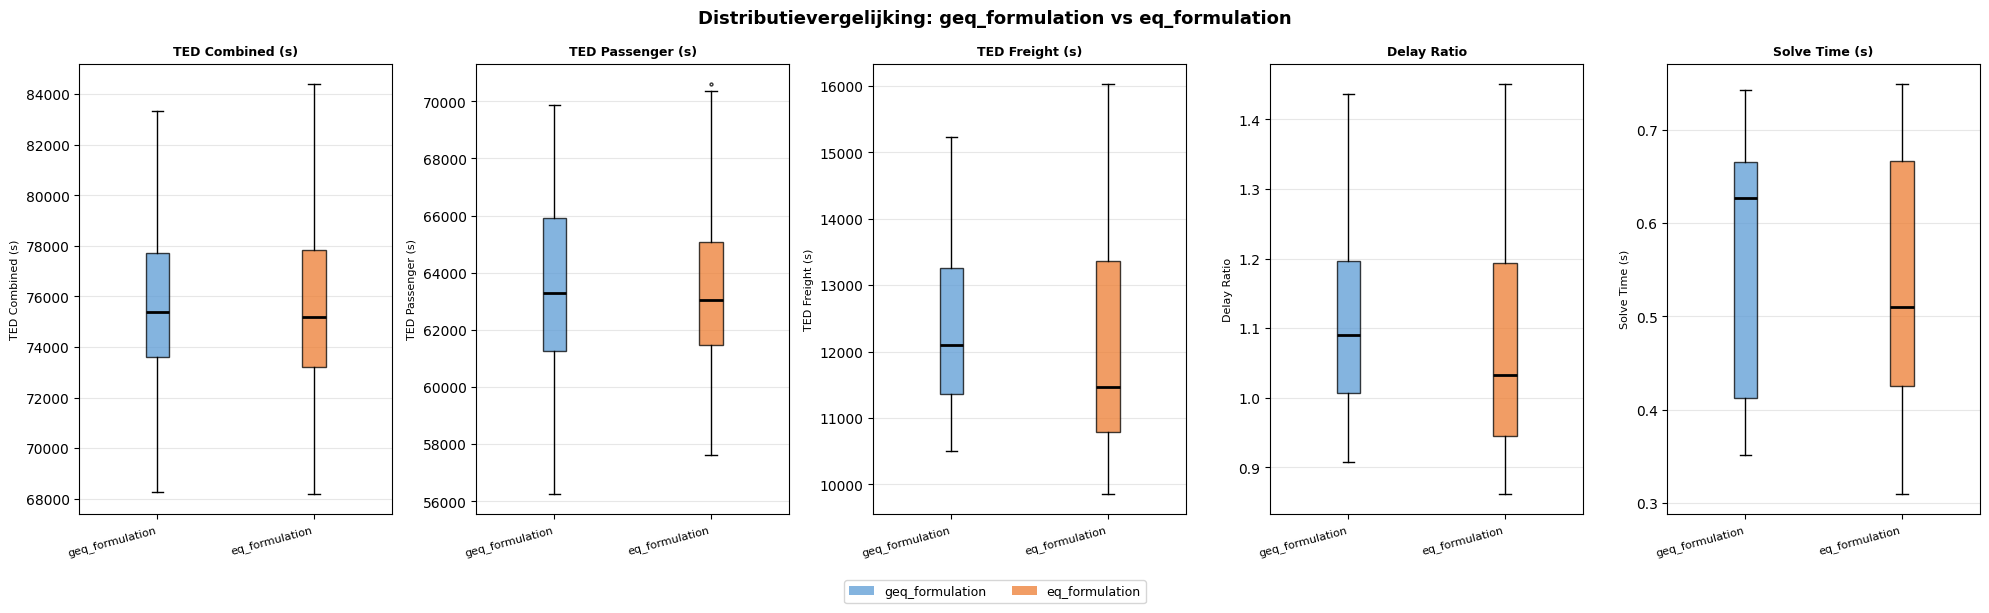

Opgeslagen: comparison_geq_formulation_vs_eq_formulation.png


In [10]:
COLORS = {EXPERIMENT_A: "#5B9BD5", EXPERIMENT_B: "#ED7D31"}
plot_metrics = [
    ("TED_combined",    "TED Combined (s)"),
    ("TED_passenger",   "TED Passenger (s)"),
    ("TED_freight",     "TED Freight (s)"),
    ("delay_ratio",     "Delay Ratio"),
    ("total_solve_time","Solve Time (s)"),
]

n_metrics = len(plot_metrics)
fig, axes = plt.subplots(1, n_metrics, figsize=(4 * n_metrics, 6))
fig.suptitle(
    f"Distributievergelijking: {EXPERIMENT_A} vs {EXPERIMENT_B}",
    fontsize=13, fontweight="bold"
)

for ax, (metric, ylabel) in zip(axes, plot_metrics):
    data_by_exp = [
        raw_combined[raw_combined["experiment"] == exp][metric].dropna().values
        for exp in [EXPERIMENT_A, EXPERIMENT_B]
    ]
    bp = ax.boxplot(
        data_by_exp,
        patch_artist=True,
        medianprops=dict(color="black", linewidth=2),
        flierprops=dict(marker=".", markersize=4, alpha=0.5),
    )
    for patch, exp in zip(bp["boxes"], [EXPERIMENT_A, EXPERIMENT_B]):
        patch.set_facecolor(COLORS[exp])
        patch.set_alpha(0.75)

    ax.set_xticks([1, 2])
    ax.set_xticklabels([EXPERIMENT_A, EXPERIMENT_B], rotation=15, ha="right", fontsize=8)
    ax.set_title(ylabel, fontweight="bold", fontsize=9)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.grid(axis="y", alpha=0.3)

legend_patches = [
    mpatches.Patch(facecolor=COLORS[exp], label=exp, alpha=0.75)
    for exp in [EXPERIMENT_A, EXPERIMENT_B]
]
fig.legend(handles=legend_patches, loc="lower center", ncol=2,
           fontsize=9, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout(rect=[0, 0.04, 1, 1])
plot_path = BASE / f"comparison_{EXPERIMENT_A}_vs_{EXPERIMENT_B}.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Opgeslagen: {plot_path.name}")

### 4.5 Vergelijking per configuratie

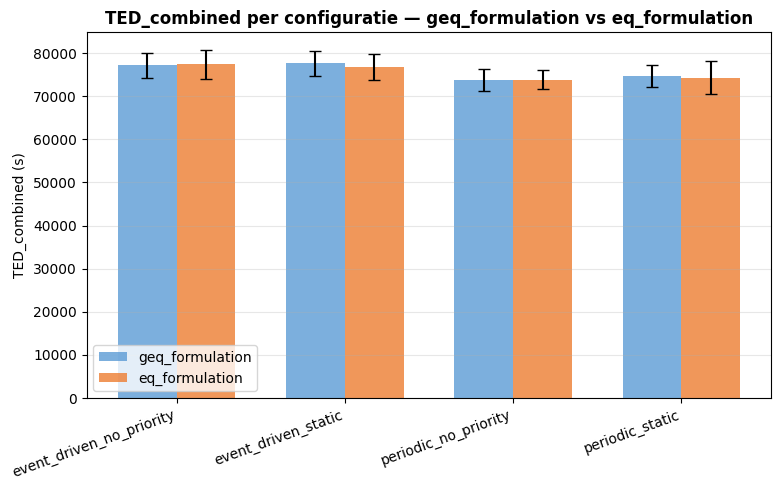

In [11]:
metric = "TED_combined"   # ← aanpassen indien gewenst

n_configs = len(configs_common)
x = np.arange(n_configs)
width = 0.35

means_A = [raw_A[(raw_A["config"] == c) & (raw_A["deadlock"] != True)][metric].mean()
           for c in configs_common]
means_B = [raw_B[(raw_B["config"] == c) & (raw_B["deadlock"] != True)][metric].mean()
           for c in configs_common]
stds_A  = [raw_A[(raw_A["config"] == c) & (raw_A["deadlock"] != True)][metric].std()
           for c in configs_common]
stds_B  = [raw_B[(raw_B["config"] == c) & (raw_B["deadlock"] != True)][metric].std()
           for c in configs_common]

fig, ax = plt.subplots(figsize=(max(8, 2 * n_configs), 5))
bars_A = ax.bar(x - width/2, means_A, width, yerr=stds_A, label=EXPERIMENT_A,
                color=COLORS[EXPERIMENT_A], alpha=0.8, capsize=4)
bars_B = ax.bar(x + width/2, means_B, width, yerr=stds_B, label=EXPERIMENT_B,
                color=COLORS[EXPERIMENT_B], alpha=0.8, capsize=4)

ax.set_xticks(x)
ax.set_xticklabels(configs_common, rotation=20, ha="right")
ax.set_ylabel(f"{metric} (s)")
ax.set_title(f"{metric} per configuratie — {EXPERIMENT_A} vs {EXPERIMENT_B}",
             fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(BASE / f"per_config_{metric}_{EXPERIMENT_A}_vs_{EXPERIMENT_B}.png",
            dpi=150, bbox_inches="tight")
plt.show()